In [32]:
import os
import cv2
import csv
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torchvision

import random

In [33]:
def seed_everything(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [34]:
path = kagglehub.dataset_download("akash2sharma/tiny-imagenet")

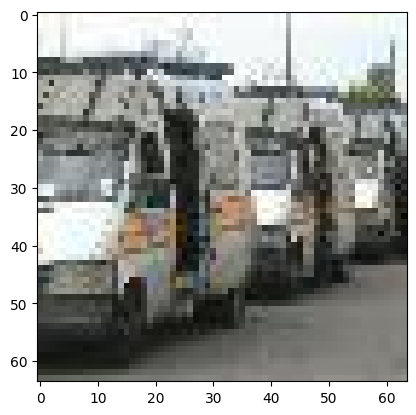

In [35]:
#データセット
seed_everything(0)

image_paths_train = []
DATA_DIR_train = f"{path}/tiny-imagenet-200/train"
for D in os.listdir(DATA_DIR_train):
  image_dir = f"{DATA_DIR_train}/{D}/images"
  image_paths_train.extend([f"{image_dir}/{IP}" for IP in os.listdir(image_dir)])

datas = []
for img_path in image_paths_train:
    class_id = img_path.split("/")[-3]
    datas.append({"image_path": img_path, "label": class_id})

idx = np.random.randint(0, len(datas))
image = Image.open(datas[idx]["image_path"])

fig = plt.figure()
ax = fig.add_subplot()
ax.imshow(image)

In [36]:
# クラス定義（Tiny ImageNet）
seed_everything(0)

WNID_FILE = f"{path}/tiny-imagenet-200/wnids.txt"
with open(WNID_FILE, "r") as f:
    wnids = [line.strip() for line in f]

category_to_index = {wnid: i for i, wnid in enumerate(wnids)}
index_to_category = {i: wnid for wnid, i in category_to_index.items()}

x = []
t = []

for D in datas:
    x.append(D["image_path"])
    t.append(category_to_index[D["label"]])

tmp = list(zip(x, t))
train_tmp, test_tmp = train_test_split(tmp, test_size=0.1, random_state=42) #データを9:1に分割

train_x, train_t = zip(*train_tmp)
test_x, test_t = zip(*test_tmp)

Text(0.5, 1.0, 'preprocessed')

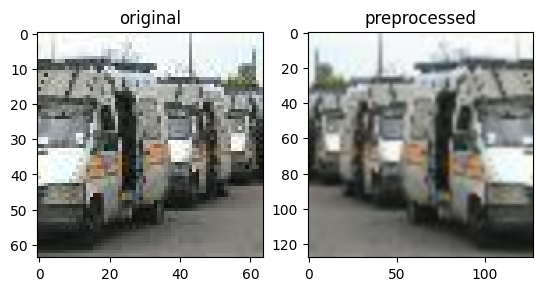

In [37]:
# 画像の前処理関数
seed_everything(0)

image_preprocessor = torchvision.transforms.Compose([
    torchvision.transforms.Resize(128),
    torchvision.transforms.RandomCrop(128),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),])

image = Image.open(datas[idx]["image_path"])
preprocessed_image = image_preprocessor(image)

fig = plt.figure()
ax = fig.add_subplot(1, 2, 1)
ax.imshow(image)
ax.set_title("original")

ax = fig.add_subplot(1, 2, 2)
ax.imshow(preprocessed_image.permute(1, 2, 0))
ax.set_title("preprocessed")

In [38]:
# 学習のパラメータ
EPOCHS = 100
BATCH_SIZE =  512
LEARNING_RATE = 0.001

In [39]:
seed_everything(0)
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, teacher_signals, transform):

        self.image_paths = image_paths
        self.teacher_signals = teacher_signals
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open( self.image_paths[idx] ).convert('RGB')
        input = self.transform(image)

        teacher_signal = self.teacher_signals[idx]
        teacher_signal = torch.tensor(teacher_signal, dtype=torch.long)

        return input, teacher_signal

def collate_fn(batch):
    inputs = torch.stack( [B[0] for B in batch] )
    teacher_signals = torch.stack( [B[1] for B in batch] )

    return inputs, teacher_signals

train_dataset = MyDataset(image_paths = train_x,
                          teacher_signals = train_t,
                          transform = image_preprocessor)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    collate_fn = collate_fn,
    num_workers = 2,
    shuffle = True,
    pin_memory = True,
    persistent_workers = True,
)

image_preprocessor = torchvision.transforms.Compose([
    torchvision.transforms.Resize(128),
    torchvision.transforms.RandomCrop(128),
    torchvision.transforms.ToTensor(),
])
test_dataset = MyDataset(image_paths = test_x,
                          teacher_signals = test_t,
                          transform = image_preprocessor)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    collate_fn = collate_fn,
    num_workers = 2,
    pin_memory = True,
    persistent_workers = True,
)

I, T = next(iter(train_dataloader))
I.shape, T.shape

(torch.Size([512, 3, 128, 128]), torch.Size([512]))

In [40]:
seed_everything(0)
class MyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = torch.nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(32)
        self.act1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2)

        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(64)
        self.act2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2)

        self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = torch.nn.BatchNorm2d(128)
        self.act3 = torch.nn.ReLU()
        self.pool3 = torch.nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = torch.nn.Linear(128, 64)
        self.act4 = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(64, 200)

    def forward(self, x):
        y = self.act1(self.bn1(self.conv1(x)))
        y = self.pool1(y)

        y = self.act2(self.bn2(self.conv2(y)))
        y = self.pool2(y)

        y = self.act3(self.bn3(self.conv3(y)))
        y = self.pool3(y)

        y = torch.flatten(y, 1)
        y = self.act4(self.fc1(y))
        y = self.fc2(y)
        return y

seed_everything(0)
model = MyModel()
model(I[:1])

tensor([[-0.1781, -0.0165,  0.0649, -0.0342,  0.0074,  0.0731,  0.0770,  0.2737,
          0.1320, -0.0006,  0.1524, -0.0628,  0.0729,  0.1703, -0.0927,  0.0199,
         -0.0681,  0.0481,  0.0831,  0.0237, -0.1061, -0.0512,  0.0851,  0.1307,
          0.1462, -0.0132,  0.0556,  0.1276,  0.1267, -0.1816, -0.0276, -0.0353,
         -0.1024, -0.0122,  0.0981,  0.1539, -0.0256, -0.0178, -0.1572, -0.0245,
         -0.0200, -0.3514, -0.0627, -0.0266, -0.1187,  0.1295,  0.1298,  0.1430,
          0.0972,  0.0189,  0.1392, -0.1699, -0.0287, -0.1035,  0.2041, -0.0983,
          0.0815,  0.0320, -0.0878,  0.2176, -0.1612, -0.0850,  0.0524, -0.1168,
         -0.0960,  0.0166,  0.0071, -0.0963,  0.0074, -0.1205,  0.0281, -0.0550,
          0.0175,  0.1376,  0.0153, -0.0948, -0.0211,  0.0475,  0.0924, -0.0265,
         -0.0653, -0.0873,  0.1132, -0.1309, -0.0087,  0.1054, -0.1407, -0.0358,
          0.0017, -0.0485, -0.0379,  0.0894, -0.0349, -0.1795, -0.1490,  0.1478,
         -0.0534, -0.1413, -

In [41]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [42]:
#学習の関数
seed_everything(0)
def loss_func(Y, T):
    E = ((-1.0 * T * torch.log(Y + 1e-6))).sum(dim=1).mean()
    return E

def accuracy_func(Y, T):
    Y = Y.argmax(dim=1)
    A = (Y == T).float().mean()
    return A

def iteration(X_batch, T_batch, model, optimizer = None):
    X_batch = X_batch.to(device)
    T_batch = T_batch.to(device)

    # 学習する場合
    if optimizer is not None:
        optimizer.zero_grad()
        Y_batch = model(X_batch)
        E_batch = loss_func(Y_batch, T_batch)
        E_batch.backward()
        optimizer.step()

    # 学習しない場合
    else:
        with torch.no_grad():
            Y_batch = model(X_batch)
            E_batch = loss_func(Y_batch, T_batch)

    A_batch = accuracy_func(Y_batch, T_batch)

    return E_batch.item(), A_batch.item()

def epoch(dataloader, model, optimizer = None):

    E = 0
    A = 0
    total_data = 0

    pb = tqdm(dataloader)
    for X_batch, T_batch in pb:

        E_batch, A_batch = iteration(X_batch, T_batch, model, optimizer)

        # ミニバッチの平均になっている誤差と精度を総和に戻す
        E += E_batch * len(X_batch)
        A += A_batch * len(X_batch)
        total_data += len(X_batch)

        pb.set_postfix({"loss": E / total_data,
                        "accuracy": A / total_data})

    # 全データでの平均の誤差と精度
    E /= total_data
    A /= total_data

    return E, A

In [43]:
#Adam
model = MyModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)
loss_func = torch.nn.CrossEntropyLoss()

Adam_train_loss_history = list()
Adam_train_accuracy_history = list()
Adam_test_loss_history = list()
Adam_test_accuracy_history = list()

E, A = epoch(train_dataloader, model)
Adam_train_loss_history.append(E)
Adam_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
Adam_test_loss_history.append(E)
Adam_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    Adam_train_loss_history.append(E)
    Adam_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    Adam_test_loss_history.append(E)
    Adam_test_accuracy_history.append(A)

100%|██████████| 20/20 [00:04<00:00,  4.47it/s, loss=5.31, accuracy=0.0038] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  7.63it/s, loss=4.57, accuracy=0.0656]


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  7.95it/s, loss=4.53, accuracy=0.073] 


...

100%|██████████| 20/20 [00:02<00:00,  8.28it/s, loss=3.39, accuracy=0.253]


epoch; 99


100%|██████████| 20/20 [00:02<00:00,  8.74it/s, loss=3.03, accuracy=0.307]


epoch; 100


100%|██████████| 20/20 [00:02<00:00,  8.36it/s, loss=3.12, accuracy=0.297]


In [44]:
#ADINA
class ADINA(torch.optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE, beta_1 = 0.9, beta_2 = 0.9, a = 0.1, b = 0.01, c = 1):
        defaults = {"lr":lr, "beta_1":beta_1, "beta_2":beta_2, "a":a, "b":b}
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta_1 = group["beta_1"]
            beta_2 = group["beta_2"]
            a = group["a"]
            b = group["b"]

            for w in group["params"]:
                if w.grad is None:
                    continue

                state = self.state[w]
                if len(state) == 0:
                    state["m"] = torch.zeros_like(w)
                    state["g"] = torch.zeros_like(w)
                    state["v"] = torch.zeros_like(w)
                    state["step"] = 0
                state["step"] += 1
                grad = w.grad
                m = state["m"]
                v = state["v"]
                step = state["step"]

                m.mul_(beta_1).add_(grad * (1-a*b) / a , alpha = 1.0 - beta_1)
                g = m / (1 - beta_1 ** step) + b * grad
                v.mul_(beta_2).add_(g*g , alpha = 1 - beta_2)
                w.sub_(g / (v / (1 - beta_2 ** step) + 1e-8)**0.5 , alpha = lr)


model = MyModel().to(device)
optimizer = ADINA(model.parameters(), lr = LEARNING_RATE)
loss_func = torch.nn.CrossEntropyLoss()

ADINA_train_loss_history = list()
ADINA_train_accuracy_history = list()
ADINA_test_loss_history = list()
ADINA_test_accuracy_history = list()

E, A = epoch(train_dataloader, model)
ADINA_train_loss_history.append(E)
ADINA_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
ADINA_test_loss_history.append(E)
ADINA_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    ADINA_train_loss_history.append(E)
    ADINA_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    ADINA_test_loss_history.append(E)
    ADINA_test_accuracy_history.append(A)

100%|██████████| 20/20 [00:02<00:00,  8.20it/s, loss=5.31, accuracy=0.0058] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  7.87it/s, loss=4.81, accuracy=0.056] 


epoch; 2


100%|██████████| 20/20 [00:04<00:00,  4.41it/s, loss=4.95, accuracy=0.0546]


...

100%|██████████| 20/20 [00:01<00:00, 10.79it/s, loss=3.2, accuracy=0.298] 


epoch; 99


100%|██████████| 20/20 [00:03<00:00,  5.12it/s, loss=2.96, accuracy=0.328]


epoch; 100


100%|██████████| 20/20 [00:01<00:00, 10.82it/s, loss=3.04, accuracy=0.311]


In [45]:
#Schedule-Free_ADINA
seed_everything(0)
class ScheduleFree_ADINA(torch.optim.Optimizer):
    def __init__(self, params, lr=LEARNING_RATE, lamda=0.3, beta1 =0.9, beta2 = 0.999, a = 0.1, b = 0.01, eps = 1e-8):
        defaults = {"lr":lr, "lamda":lamda, "beta1":beta1, "beta2":beta2, "a":a, "b":b, "eps":eps}
        super().__init__(params, defaults)
        self.train_mode = True

    def train(self):
        if not self.train_mode:
            for group in self.param_groups:
                lamda = group["lamda"]
                for p in group["params"]:
                    if p.grad is None:
                        continue
                    state = self.state[p]
                    p.data.copy_(state["w"])
                    p.data.lerp_(state["x"], lamda)
            self.train_mode = True

    def eval(self):
        if self.train_mode:
            for group in self.param_groups:
                for p in group["params"]:
                    if p.grad is None:
                        continue
                    state = self.state[p]
                    p.data.copy_(state["x"])
            self.train_mode = False

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            lamda = group["lamda"]
            beta1 = group["beta1"]
            beta2 = group["beta2"]
            a = group["a"]
            b = group["b"]
            eps = group["eps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]
                if len(state) == 0:
                    state["w"] = p.data.clone()
                    state["x"] = p.data.clone()
                    state["g"] = torch.zeros_like(p.data)
                    state["v"] = torch.zeros_like(p.data)
                    state["k"] = 0

                state["k"] += 1
                k = state["k"]

                w = state["w"]
                x = state["x"]
                g = state["g"]
                v = state["v"]
                grad = p.grad

                g.mul_(beta1).add_(grad * ((1 - a*b) / a), alpha = 1.0 - beta1)
                v.mul_(beta2).add_(grad**2, alpha = 1.0 - beta2)
                w.sub_((g / (1 - beta1**(k+1)) + b * grad) / ((v / (1-beta2**(k+1)))**0.5 + eps), alpha = lr)
                x.lerp_(w, 1/(k+1))

                if self.train_mode:
                    p.data.copy_(w)
                    p.data.lerp_(x, lamda)
                else:
                    p.data.copy_(x)

        return loss


model = MyModel().to(device)
optimizer = ScheduleFree_ADINA(model.parameters(), lr = LEARNING_RATE)
loss_func = torch.nn.CrossEntropyLoss()

SF_ADINA_train_loss_history = list()
SF_ADINA_train_accuracy_history = list()
SF_ADINA_test_loss_history = list()
SF_ADINA_test_accuracy_history = list()

E, A = epoch(train_dataloader, model)
SF_ADINA_train_loss_history.append(E)
SF_ADINA_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
SF_ADINA_test_loss_history.append(E)
SF_ADINA_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    SF_ADINA_train_loss_history.append(E)
    SF_ADINA_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    SF_ADINA_test_loss_history.append(E)
    SF_ADINA_test_accuracy_history.append(A)

100%|██████████| 20/20 [00:01<00:00, 10.15it/s, loss=5.31, accuracy=0.0038] 


epoch; 1


100%|██████████| 20/20 [00:01<00:00, 10.87it/s, loss=4.66, accuracy=0.0568]


epoch; 2


100%|██████████| 20/20 [00:01<00:00, 11.16it/s, loss=4.21, accuracy=0.111]


...

100%|██████████| 20/20 [00:02<00:00,  7.77it/s, loss=3.01, accuracy=0.31] 


epoch; 99


100%|██████████| 20/20 [00:02<00:00,  7.67it/s, loss=3.15, accuracy=0.294]


epoch; 100


100%|██████████| 20/20 [00:02<00:00,  7.93it/s, loss=3.01, accuracy=0.308]


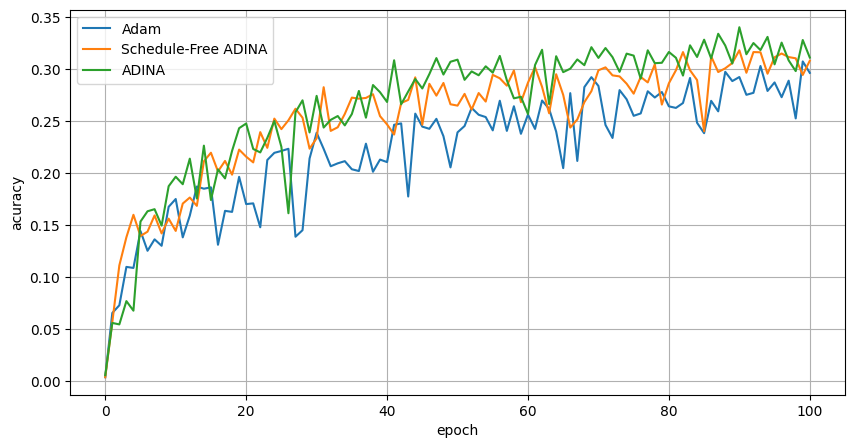

In [60]:
fig = plt.figure(figsize = (10, 5))
ax = fig.add_subplot()
ax.plot(Adam_test_accuracy_history, label = "Adam")
ax.plot(SF_ADINA_test_accuracy_history, label = "Schedule-Free ADINA")
ax.plot(ADINA_test_accuracy_history, label = "ADINA")
ax.set_xlabel("epoch")
ax.set_ylabel("acuracy")
ax.grid()
ax.legend()